# Shielded CPW Impedance Calculator

This notebook calculates shielded coplanar waveguide (SCPW) characteristic impedance using the conformal-mapping model you provided.

## Geometry definition

- `s`: track width (center conductor width)
- `w`: single-side gap width
- `a = s`
- `b = s + 2w`
- `h_t`: top shield or cavity-roof height
- `h_b`: bottom substrate height
- `\epsilon_t`: relative permittivity of the top layer
- `\epsilon_b`: relative permittivity of the bottom substrate

## Equations

\begin{align}
k_t &= \frac{\tanh\left(\frac{\pi a}{4 h_t}\right)}{\tanh\left(\frac{\pi b}{4 h_t}\right)} \\
k_b &= \frac{\tanh\left(\frac{\pi a}{4 h_b}\right)}{\tanh\left(\frac{\pi b}{4 h_b}\right)} \\
k_t' &= \sqrt{1-k_t^2} \\
k_b' &= \sqrt{1-k_b^2} \\
\epsilon_{\mathrm{eff}} &= \frac{\epsilon_t\,\frac{K(k_t)}{K(k_t')} + \epsilon_b\,\frac{K(k_b)}{K(k_b')}}{\frac{K(k_t)}{K(k_t')} + \frac{K(k_b)}{K(k_b')}} \\
Z_0 &= \frac{60\pi}{\sqrt{\epsilon_{\mathrm{eff}}}}\cdot\frac{1}{\frac{K(k_t)}{K(k_t')} + \frac{K(k_b)}{K(k_b')}}
\end{align}

where $K(\cdot)$ is the complete elliptic integral of the first kind.

In [1]:
import numpy as np
from scipy.special import ellipk


def K_of_x(x: float) -> float:
    """Complete elliptic integral K(x), with scipy ellipk parameter m = x^2."""
    x = float(x)
    if not (0.0 < x < 1.0):
        raise ValueError(f"Input to K(x) must satisfy 0 < x < 1, got {x}.")
    return float(ellipk(x**2))


def shielded_cpw(s_mm: float, w_mm: float, h_t_mm: float, h_b_mm: float, eps_t: float, eps_b: float) -> dict:
    """
    Calculate impedance and effective permittivity for a shielded coplanar waveguide.

    Parameters
    ----------
    s_mm : trace width
    w_mm : single-side gap width
    h_t_mm : top shield height
    h_b_mm : bottom substrate height
    eps_t : top-layer relative permittivity
    eps_b : bottom-layer relative permittivity
    """
    s = float(s_mm)
    w = float(w_mm)
    h_t = float(h_t_mm)
    h_b = float(h_b_mm)
    eps_t = float(eps_t)
    eps_b = float(eps_b)

    if s <= 0 or w <= 0 or h_t <= 0 or h_b <= 0:
        raise ValueError("s, w, h_t, and h_b must all be positive.")
    if eps_t <= 0 or eps_b <= 0:
        raise ValueError("eps_t and eps_b must be positive.")

    a = s
    b = s + 2.0 * w

    k_t = np.tanh(np.pi * a / (4.0 * h_t)) / np.tanh(np.pi * b / (4.0 * h_t))
    k_b = np.tanh(np.pi * a / (4.0 * h_b)) / np.tanh(np.pi * b / (4.0 * h_b))
    k_t_prime = np.sqrt(1.0 - k_t**2)
    k_b_prime = np.sqrt(1.0 - k_b**2)

    for name, value in (("k_t", k_t), ("k_t'", k_t_prime), ("k_b", k_b), ("k_b'", k_b_prime)):
        if not (0.0 < value < 1.0):
            raise ValueError(f"{name} out of domain (0, 1): {value}")

    ratio_t = K_of_x(k_t) / K_of_x(k_t_prime)
    ratio_b = K_of_x(k_b) / K_of_x(k_b_prime)

    eps_eff = (eps_t * ratio_t + eps_b * ratio_b) / (ratio_t + ratio_b)
    z0 = (60.0 * np.pi / np.sqrt(eps_eff)) * (1.0 / (ratio_t + ratio_b))

    return {
        "s_mm": s,
        "w_mm": w,
        "h_t_mm": h_t,
        "h_b_mm": h_b,
        "eps_t": eps_t,
        "eps_b": eps_b,
        "a_mm": a,
        "b_mm": b,
        "k_t": float(k_t),
        "k_t_prime": float(k_t_prime),
        "k_b": float(k_b),
        "k_b_prime": float(k_b_prime),
        "ratio_t": float(ratio_t),
        "ratio_b": float(ratio_b),
        "geom_factor": float(1.0 / (ratio_t + ratio_b)),
        "eps_eff": float(eps_eff),
        "z0_ohm": float(z0),
    }


def cpw_impedance(s_mm: float, w_mm: float, h_t_mm: float, h_b_mm: float, eps_t: float, eps_b: float) -> dict:
    """Backward-compatible notebook entry point for the shielded CPW model."""
    return shielded_cpw(s_mm=s_mm, w_mm=w_mm, h_t_mm=h_t_mm, h_b_mm=h_b_mm, eps_t=eps_t, eps_b=eps_b)

In [4]:
# Example shielded CPW values
s_mm = 7      # track width
w_mm = 6      # single-side gap width
h_t_mm = 1000    # top shield height
h_b_mm = 1000    # bottom substrate height
eps_t = 1.0   # top-layer relative permittivity (air/vacuum)
eps_b = 11.0  # bottom substrate relative permittivity

result = cpw_impedance(
    s_mm=s_mm,
    w_mm=w_mm,
    h_t_mm=h_t_mm,
    h_b_mm=h_b_mm,
    eps_t=eps_t,
    eps_b=eps_b,
 )

print("Shielded CPW calculation")
print("-" * 40)
print(f"s (mm)   : {result['s_mm']:.4f}")
print(f"w (mm)   : {result['w_mm']:.4f}")
print(f"a (mm)   : {result['a_mm']:.4f}")
print(f"b (mm)   : {result['b_mm']:.4f}  (b = s + 2w)")
print(f"h_t (mm) : {result['h_t_mm']:.4f}")
print(f"h_b (mm) : {result['h_b_mm']:.4f}")
print(f"eps_t    : {result['eps_t']:.4f}")
print(f"eps_b    : {result['eps_b']:.4f}")
print()
print(f"k_t      : {result['k_t']:.6f}")
print(f"k_t'     : {result['k_t_prime']:.6f}")
print(f"k_b      : {result['k_b']:.6f}")
print(f"k_b'     : {result['k_b_prime']:.6f}")
print()
print(f"eps_eff  : {result['eps_eff']:.6f}")
print(f"Z0 (ohm) : {result['z0_ohm']:.4f}")

Shielded CPW calculation
----------------------------------------
s (mm)   : 7.0000
w (mm)   : 6.0000
a (mm)   : 7.0000
b (mm)   : 19.0000  (b = s + 2w)
h_t (mm) : 1000.0000
h_b (mm) : 1000.0000
eps_t    : 1.0000
eps_b    : 11.0000

k_t      : 0.368445
k_t'     : 0.929650
k_b      : 0.368445
k_b'     : 0.929650

eps_eff  : 6.000000
Z0 (ohm) : 57.5332


In [2]:

import matplotlib.pyplot as plt
h_t_sweep_mm = np.logspace(np.log10(2.0), np.log10(2000.0), 500)


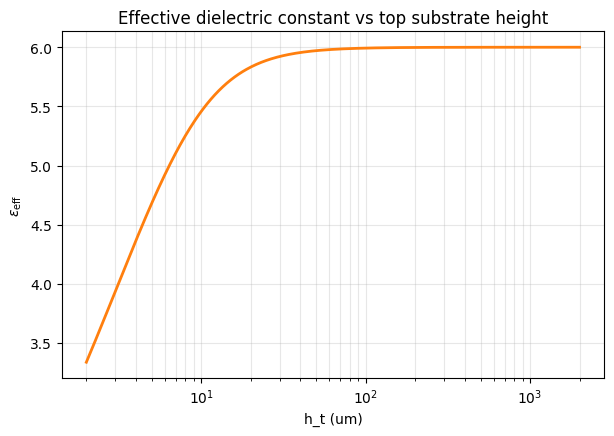

In [145]:

eps_eff_sweep = np.array(
    [
        cpw_impedance(
            s_mm=s_mm,
            w_mm=w_mm,
            h_t_mm=h_val,
            h_b_mm=h_b_mm,
            eps_t=eps_t,
            eps_b=eps_b,
        )["eps_eff"]
        for h_val in h_t_sweep_mm
    ],
    dtype=float,
 )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(h_t_sweep_mm, eps_eff_sweep, linewidth=2, color="tab:orange")
ax.set_xscale("log")
ax.set_xlabel("h_t (um)")
ax.set_ylabel(r"$\epsilon_{\mathrm{eff}}$")
ax.set_title("Effective dielectric constant vs top substrate height")
ax.grid(True, which="both", alpha=0.3)
plt.show()

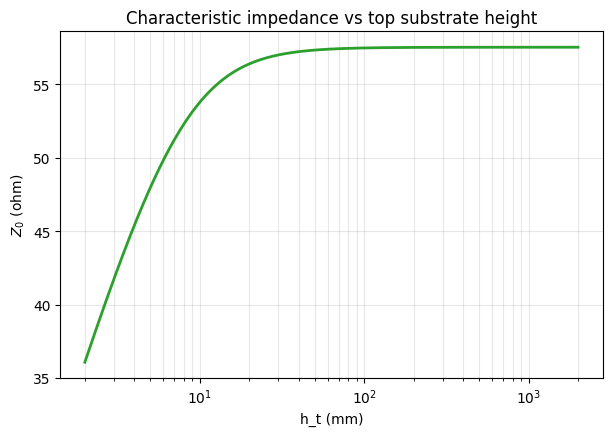

In [146]:
z0_sweep = np.array(
    [
        cpw_impedance(
            s_mm=s_mm,
            w_mm=w_mm,
            h_t_mm=h_val,
            h_b_mm=h_b_mm,
            eps_t=eps_t,
            eps_b=eps_b,
        )["z0_ohm"]
        for h_val in h_t_sweep_mm
    ],
    dtype=float,
 )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(h_t_sweep_mm, z0_sweep, linewidth=2, color="tab:green")
ax.set_xscale("log")
ax.set_xlabel("h_t (mm)")
ax.set_ylabel(r"$Z_0$ (ohm)")
ax.set_title("Characteristic impedance vs top substrate height")
ax.grid(True, which="both", alpha=0.3)
plt.show()

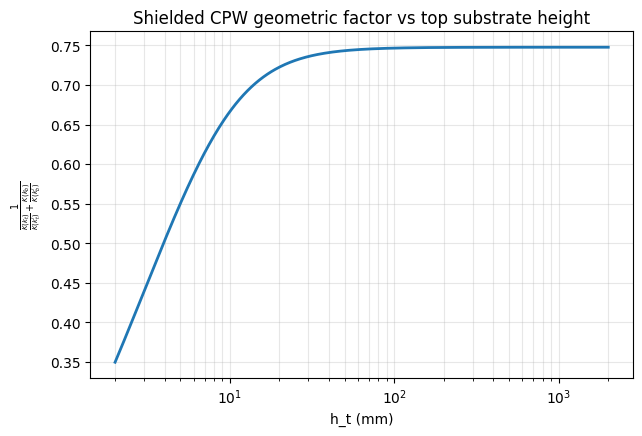

In [147]:
factor_sweep = np.array(
    [
        cpw_impedance(
            s_mm=s_mm,
            w_mm=w_mm,
            h_t_mm=h_val,
            h_b_mm=h_b_mm,
            eps_t=eps_t,
            eps_b=eps_b,
        )["geom_factor"]
        for h_val in h_t_sweep_mm
    ],
    dtype=float,
 )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(h_t_sweep_mm, factor_sweep, linewidth=2, color="tab:blue")
ax.set_xscale("log")
ax.set_xlabel("h_t (mm)")
ax.set_ylabel(r"$\frac{1}{\frac{K(k_t)}{K(k_t')} + \frac{K(k_b)}{K(k_b')}}$")
ax.set_title("Shielded CPW geometric factor vs top substrate height")
ax.grid(True, which="both", alpha=0.3)
plt.show()

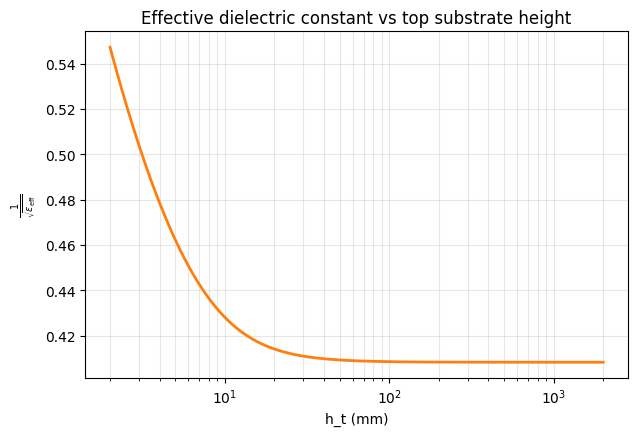

In [148]:

eps_eff_sweep = np.array(
    [
        cpw_impedance(
            s_mm=s_mm,
            w_mm=w_mm,
            h_t_mm=h_val,
            h_b_mm=h_b_mm,
            eps_t=eps_t,
            eps_b=eps_b,
        )["eps_eff"]
        for h_val in h_t_sweep_mm
    ],
    dtype=float,
 )

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(h_t_sweep_mm, 1/np.sqrt(eps_eff_sweep), linewidth=2, color="tab:orange")
ax.set_xscale("log")
ax.set_xlabel("h_t (mm)")
ax.set_ylabel(r"$\frac{1}{\sqrt{\epsilon_{\mathrm{eff}}}}$")
ax.set_title("Effective dielectric constant vs top substrate height")
ax.grid(True, which="both", alpha=0.3)
plt.show()

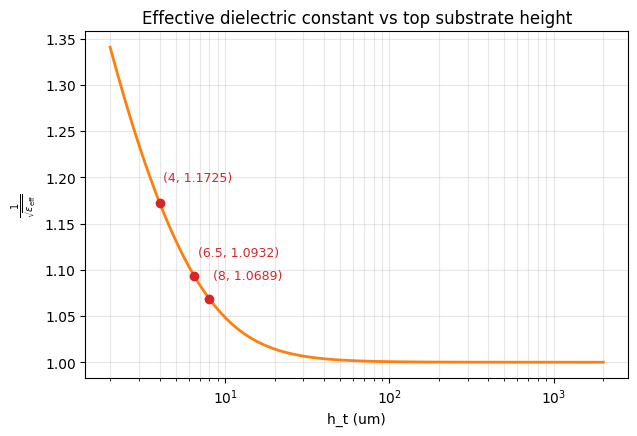

Queried points (x, y):
x=4, y=1.172463
x=6.5, y=1.093234
x=8, y=1.068889


In [5]:
eps_eff_sweep = np.array(
    [
        cpw_impedance(
            s_mm=s_mm,
            w_mm=w_mm,
            h_t_mm=h_val,
            h_b_mm=h_b_mm,
            eps_t=eps_t,
            eps_b=eps_b,
        )["eps_eff"]
        for h_val in h_t_sweep_mm
    ],
    dtype=float,
 )

y_curve = np.sqrt(eps_eff_sweep[-1]) / np.sqrt(eps_eff_sweep)

# Set any number of query x-points here
x_points = [4.0, 6.5, 8.0]
x_marks = np.array(sorted(set(float(x) for x in x_points)), dtype=float)

if np.any(x_marks < h_t_sweep_mm.min()) or np.any(x_marks > h_t_sweep_mm.max()):
    raise ValueError(
        f"All x_points must be within [{h_t_sweep_mm.min():.3g}, {h_t_sweep_mm.max():.3g}]"
    )

y_marks = np.interp(x_marks, h_t_sweep_mm, y_curve)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(h_t_sweep_mm, y_curve, linewidth=2, color="tab:orange")
ax.scatter(x_marks, y_marks, color="tab:red", zorder=3)
ax.set_xscale("log")

for x_val, y_val in zip(x_marks, y_marks):
    ax.text(x_val * 1.05, y_val * 1.02, f"({x_val:g}, {y_val:.4f})", color="tab:red", fontsize=9)

ax.set_xlabel("h_t (um)")
ax.set_ylabel(r"$\frac{1}{\sqrt{\epsilon_{\mathrm{eff}}}}$")
ax.set_title("Effective dielectric constant vs top substrate height")
ax.grid(True, which="both", alpha=0.3)
plt.show()

print("Queried points (x, y):")
for x_val, y_val in zip(x_marks, y_marks):
    print(f"x={x_val:g}, y={y_val:.6f}")

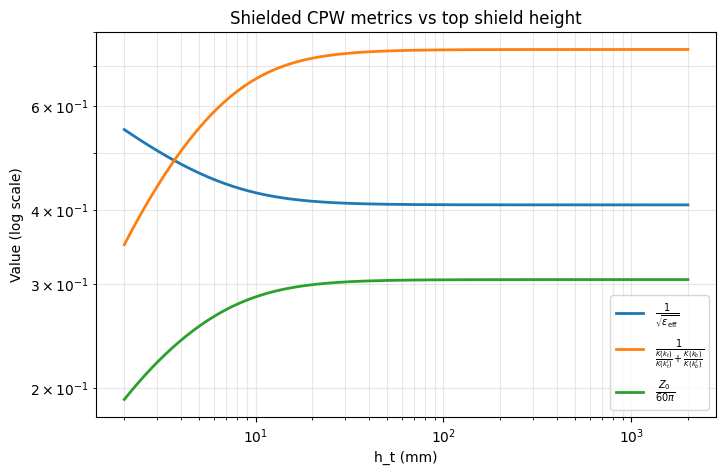

In [150]:
combined_results = [
    cpw_impedance(
        s_mm=s_mm,
        w_mm=w_mm,
        h_t_mm=h_val,
        h_b_mm=h_b_mm,
        eps_t=eps_t,
        eps_b=eps_b,
    )
    for h_val in h_t_sweep_mm
]

inv_sqrt_eps_eff = np.array([1.0 / np.sqrt(r["eps_eff"]) for r in combined_results], dtype=float)
geom_factor = np.array([r["geom_factor"] for r in combined_results], dtype=float)
z0_sweep = np.array([r["z0_ohm"] / (60.0 * np.pi) for r in combined_results], dtype=float)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h_t_sweep_mm, inv_sqrt_eps_eff, linewidth=2, label=r"$\frac{1}{\sqrt{\epsilon_{\mathrm{eff}}}}$")
ax.plot(h_t_sweep_mm, geom_factor, linewidth=2, label=r"$\frac{1}{\frac{K(k_t)}{K(k_t')} + \frac{K(k_b)}{K(k_b')}}$")
ax.plot(h_t_sweep_mm, z0_sweep, linewidth=2, label=r"$\frac{Z_0}{60\pi}$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("h_t (mm)")
ax.set_ylabel("Value (log scale)")
ax.set_title("Shielded CPW metrics vs top shield height")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.show()

In [8]:
# Input target values of normalized effective dielectric constant (y_curve)
simulation = np.array([5.6,5.7,5.8,5.9,6.1,6.0])

# measurement = np.array([5.6,5.7,5.8,5.9,6.1,6.0])

measurement = {
    "7": np.array([5.685,5.764,5.899,6.017,6.107,6.153]),
    "10": np.array([5.676,5.751,5.916,6.03,6.095,6.142]),
}

# y_targets = [1.0150, 1.0112, 1.0172, 1.019, 1.001, 1.0255]
ref = 1.0689  # reference value to scale y_targets back to the original range of y_curve

y_targets = measurement["10"] / simulation*ref
# y_targets = np.array([float(v) for v in y_targets], dtype=float) * ref

# Build monotonic arrays for interpolation y -> x
x_for_interp = h_t_sweep_mm[::-1]
y_for_interp = y_curve[::-1]

y_min, y_max = y_for_interp.min(), y_for_interp.max()
if np.any(y_targets < y_min) or np.any(y_targets > y_max):
    raise ValueError(
        f"All y_targets must be within [{y_min:.6f}, {y_max:.6f}] for this sweep."
    )

h_from_f = np.interp(y_targets, y_for_interp, x_for_interp)

print("Solved x for input y_curve values:")
for y_in, x_out in zip(y_targets, h_from_f):
    print(f"y={y_in:.6f} -> x={x_out:.6f}")

label = ["Q1", "Q2", "Q3", "Q4", "Q=", "Q+"]
x_pos = [ 0, -2500, -2500+600,     0+ 600, -2500-1300, +1800]
y_pos = [ 0,     0, -1700    , -1700     , 700       ,    +0]

Solved x for input y_curve values:
y=1.083406 -> x=7.029696
y=1.078464 -> x=7.331073
y=1.090278 -> x=6.650640
y=1.092452 -> x=6.539301
y=1.068024 -> x=8.067098
y=1.094197 -> x=6.452505


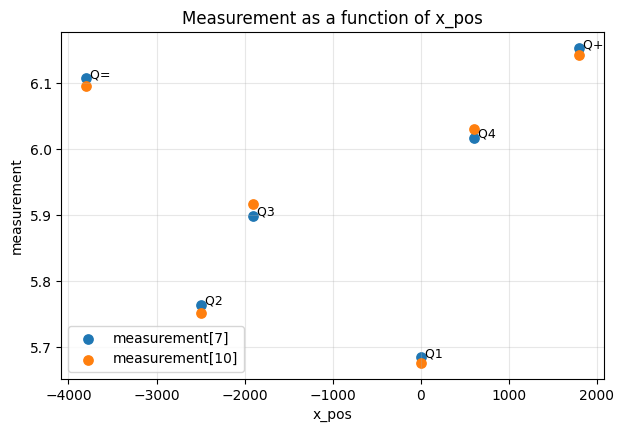

In [9]:
# Plot measurement as a function of x_pos for each measurement key
if "measurement" not in globals() or "x_pos" not in globals():
    raise ValueError("Please run the previous cell that defines measurement and x_pos first.")

x_vals = np.asarray(x_pos, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4.5))
for key in sorted(measurement.keys(), key=float):
    y_vals = np.asarray(measurement[key], dtype=float)
    if y_vals.size != x_vals.size:
        raise ValueError(f"Length mismatch for measurement[{key!r}]: len(x_pos)={x_vals.size}, len(values)={y_vals.size}")
    ax.scatter(x_vals, y_vals, s=45, label=f"measurement[{key}]")

if "label" in globals() and len(label) == x_vals.size:
    reference_vals = np.asarray(measurement[sorted(measurement.keys(), key=float)[0]], dtype=float)
    for x_i, y_i, lbl in zip(x_vals, reference_vals, label):
        ax.text(x_i, y_i, f" {lbl}", fontsize=9)

ax.set_xlabel("x_pos")
ax.set_ylabel("measurement")
ax.set_title("Measurement as a function of x_pos")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

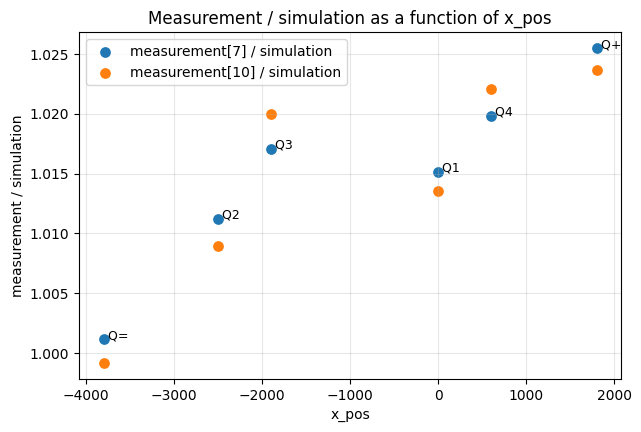

In [10]:
# Plot measurement / simulation as a function of x_pos for each measurement key
if "measurement" not in globals() or "x_pos" not in globals() or "simulation" not in globals():
    raise ValueError("Please run the previous cell that defines measurement, x_pos, and simulation first.")

x_vals = np.asarray(x_pos, dtype=float)
sim_vals = np.asarray(simulation, dtype=float)

fig, ax = plt.subplots(figsize=(7, 4.5))
for key in sorted(measurement.keys(), key=float):
    y_vals = np.asarray(measurement[key], dtype=float)
    if y_vals.size != x_vals.size:
        raise ValueError(f"Length mismatch for measurement[{key!r}]: len(x_pos)={x_vals.size}, len(values)={y_vals.size}")
    if sim_vals.size != x_vals.size:
        raise ValueError(f"Length mismatch: len(simulation)={sim_vals.size}, len(x_pos)={x_vals.size}")
    ratio_vals = y_vals / sim_vals
    ax.scatter(x_vals, ratio_vals, s=45, label=f"measurement[{key}] / simulation")

if "label" in globals() and len(label) == x_vals.size:
    reference_vals = np.asarray(measurement[sorted(measurement.keys(), key=float)[0]], dtype=float) / sim_vals
    for x_i, y_i, lbl in zip(x_vals, reference_vals, label):
        ax.text(x_i, y_i, f" {lbl}", fontsize=9)

ax.set_xlabel("x_pos")
ax.set_ylabel("measurement / simulation")
ax.set_title("Measurement / simulation as a function of x_pos")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

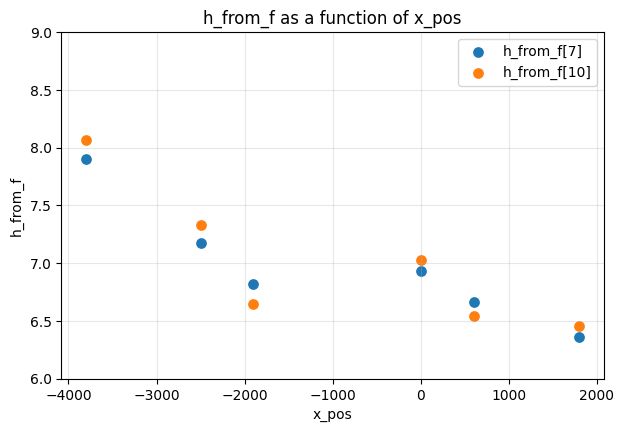

In [11]:
# Plot h_from_f as a function of x_pos for each measurement key
if "measurement" not in globals() or "x_pos" not in globals() or "simulation" not in globals() or "ref" not in globals():
    raise ValueError("Please run the previous parameter cell that defines measurement, x_pos, simulation, and ref first.")

x_vals = np.asarray(x_pos, dtype=float)
x_for_interp = h_t_sweep_mm[::-1]
y_for_interp = y_curve[::-1]

fig, ax = plt.subplots(figsize=(7, 4.5))
for key in sorted(measurement.keys(), key=float):
    y_targets_key = np.asarray(measurement[key], dtype=float) / simulation * ref
    if np.any(y_targets_key < y_for_interp.min()) or np.any(y_targets_key > y_for_interp.max()):
        raise ValueError(f"Computed targets for measurement[{key!r}] fall outside the interpolation range.")
    h_vals = np.interp(y_targets_key, y_for_interp, x_for_interp)
    if h_vals.size != x_vals.size:
        raise ValueError(f"Length mismatch for measurement[{key!r}]: len(x_pos)={x_vals.size}, len(h_vals)={h_vals.size}")
    ax.scatter(x_vals, h_vals, s=45, label=f"h_from_f[{key}]")

ax.set_xlabel("x_pos")
ax.set_ylabel("h_from_f")
ax.set_title("h_from_f as a function of x_pos")
ax.set_ylim(6.0, 9.0)
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

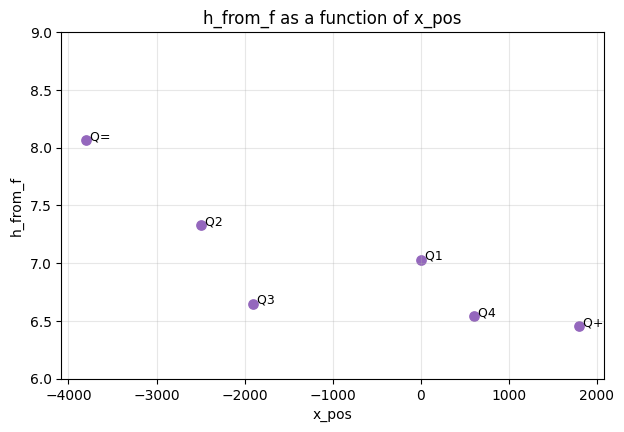

In [12]:
# Plot h_from_f as a function of x_pos
if "h_from_f" not in globals() or "x_pos" not in globals():
    raise ValueError("Please run the previous cell that defines h_from_f and x_pos first.")

x_vals = np.asarray(x_pos, dtype=float)
y_vals = np.asarray(h_from_f, dtype=float)

if x_vals.size != y_vals.size:
    raise ValueError(f"Length mismatch: len(x_pos)={x_vals.size}, len(h_from_f)={y_vals.size}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_vals, y_vals, s=45, color="tab:purple")
ax.set_xlabel("x_pos")
ax.set_ylabel("h_from_f")
ax.set_title("h_from_f as a function of x_pos")
ax.set_ylim(6.0, 9.0)
ax.grid(True, alpha=0.3)

if "label" in globals() and len(label) == x_vals.size:
    for x_i, y_i, lbl in zip(x_vals, y_vals, label):
        ax.text(x_i, y_i, f" {lbl}", fontsize=9)

plt.show()

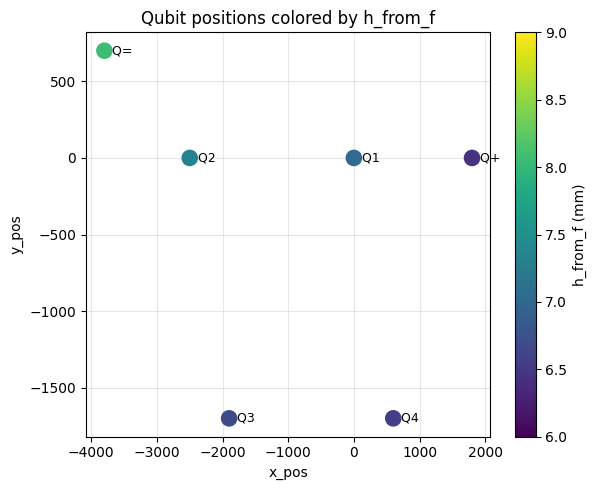

In [13]:

# Colormap scatter: x_pos vs y_pos, colored by h_from_f
if "x_pos" not in globals() or "y_pos" not in globals() or "h_from_f" not in globals():
    raise ValueError("Please run the cell that defines x_pos, y_pos, and h_from_f first.")

x_vals = np.asarray(x_pos, dtype=float)
y_vals = np.asarray(y_pos, dtype=float)
c_vals = np.asarray(h_from_f, dtype=float)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(x_vals, y_vals, c=c_vals, s=120, cmap="viridis", vmin=6.0, vmax=9.0, zorder=3)
cbar = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("h_from_f (mm)", fontsize=10)

if "label" in globals() and len(label) == x_vals.size:
    for x_i, y_i, lbl in zip(x_vals, y_vals, label):
        ax.text(x_i, y_i, f"  {lbl}", fontsize=9, va="center")

ax.set_box_aspect(1)
ax.set_xlabel("x_pos")
ax.set_ylabel("y_pos")
ax.set_title("Qubit positions colored by h_from_f")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
# Interactive 3D scatter: x_pos vs y_pos vs h_from_f, colored by h_from_f
if "x_pos" not in globals() or "y_pos" not in globals() or "h_from_f" not in globals():
    raise ValueError("Please run the cell that defines x_pos, y_pos, and h_from_f first.")

import plotly.graph_objects as go

x_vals = np.asarray(x_pos, dtype=float)
y_vals = np.asarray(y_pos, dtype=float)
z_vals = np.asarray(h_from_f, dtype=float)

text_vals = None
if "label" in globals() and len(label) == x_vals.size:
    text_vals = [str(v) for v in label]

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=x_vals,
            y=y_vals,
            z=z_vals,
            mode="markers+text" if text_vals is not None else "markers",
            text=text_vals,
            textposition="top center",
            marker=dict(
                size=8,
                color=z_vals,
                colorscale="Viridis",
                cmin=6.0,
                cmax=9.0,
                colorbar=dict(title="h_from_f (mm)"),
            ),
        )
    ]
)

fig.update_layout(
    title="Interactive 3D qubit positions colored by h_from_f",
    scene=dict(
        xaxis_title="x_pos",
        yaxis_title="y_pos",
        zaxis_title="h_from_f",
        zaxis=dict(range=[6.0, 9.0]),
    ),
    width=850,
    height=650,
)

fig.show()